In [ ]:
# ── MLOps bootstrap (auto-injected by inject_mlops_cell.py) ──────────────────
import os, warnings, mlflow
warnings.filterwarnings("ignore")

SEED = 42
import random, numpy as np
random.seed(SEED)
np.random.seed(SEED)
try:
    import torch; torch.manual_seed(SEED)
except ImportError:
    pass
try:
    import tensorflow as tf; tf.random.set_seed(SEED)
except ImportError:
    pass

_nb_name = os.path.basename(os.path.abspath("__file__") if "__file__" in dir() else ".").replace(".ipynb","")
mlflow.set_tracking_uri("sqlite:///" + str(Path(__file__).parent.parent.parent / "mlflow.db")
                        if "__file__" in dir() else "sqlite:///mlflow.db")
_exp = mlflow.set_experiment(_nb_name or "unnamed_notebook")
print(f"MLflow experiment: {_exp.name}")


# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" > TABLE OF CONTENTS<br><div>

* [IMPORTING LIBRARIES.](#1)

* [FREQUENCY DISTRIBUTION FOR CATEGORICAL COLUMNS](#2)

* [CORRELATION ANALYSIS](#3)

* [GENDER-BASED ANALYSIS](#4)
    
* [COUNT PLOT OF SCHOOLS](#5)

* [COUNT PLOT OF SEX](#6)
    
* [BOX PLOT OF AGE](#7)

* [COUNT PLOT OF FAMILY SIZE](#8)

* [COUNT PLOT OF PARENT'S COHABITATION STATUS](#9)

* [COUNT PLOT OF MOTHER'S EDUCATION LEVEL](#10)

* [COUNT PLOT OF FATHER'S EDUCATION LEVEL](#11)

* [COUNT PLOT OF TRAVEL TIME](#12)

* [COUNT PLOT OF FAILURES](#13)

* [SUMMARY STATISTICS FOR NUMERICAL COLUMNS](#14)

* [CORRELATION HEATMAP](#15)

* [DISTRIBUTION OF AGE](#16)

* [AVERAGE MOTHER'S EDUCATION LEVEL BY FAMILY SIZE](#17)

* [SEX COUNT AND PERCENTAGE](#18)

* [CROSS-TABULATION](#19)

* [BOX PLOT - MOTHER'S EDUCATION LEVEL](#20)

* [VIOLIN PLOT - AGE BY SEX](#21)

* [LOGISTIC REGRESSION](#22)

* [DECISION TREE CLASSIFIER](#23)

* [CONCLUSION](#24)


# <a id = "1"></a>
# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" > 1 - Importing Libraries. <br><div>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the data into a DataFrame
data = pd.read_csv('data.csv')


# <a id = "2"></a>
# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" > FREQUENCY DISTRIBUTION FOR CATEGORICAL COLUMNS <br><div>

In [2]:
numeric_columns = ['age', 'Medu', 'Fedu', 'traveltime', 'failures']
categorical_columns = ['school', 'sex', 'famsize', 'Pstatus']

The code computes and prints the frequency distribution of each categorical column in the dataset. It displays the count of unique values for each column.



In [3]:

# Frequency distribution for categorical columns
for column in categorical_columns:
    freq_dist = data[column].value_counts()
    print(f"\nFrequency Distribution for {column}:")
    print(freq_dist)


Frequency Distribution for school:
GP    349
MS     46
Name: school, dtype: int64

Frequency Distribution for sex:
F    208
M    187
Name: sex, dtype: int64

Frequency Distribution for famsize:
GT3    281
LE3    114
Name: famsize, dtype: int64

Frequency Distribution for Pstatus:
T    354
A     41
Name: Pstatus, dtype: int64


# <a id = "3"></a>
# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" > CORRELATION ANALYSIS <br><div>

The code calculates the correlation matrix for the numeric columns in the dataset and visualizes it using a heatmap. The heatmap displays the strength and direction of the correlations between the variables.



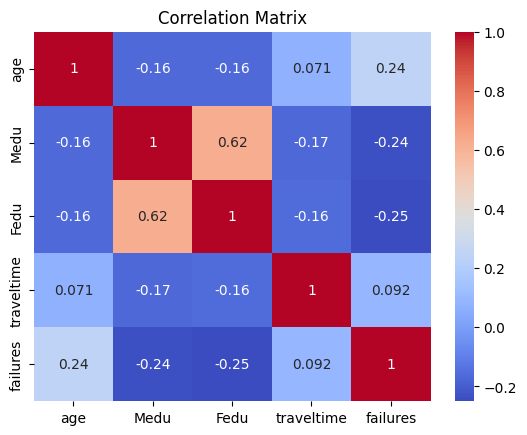

In [4]:
# Correlation Analysis
corr_matrix = data[numeric_columns].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

The code calculates the correlation coefficient between the "Medu" (mother's education) and "Fedu" (father's education) columns in the dataset and prints the correlation value. The correlation coefficient measures the linear relationship between the two variables.



In [5]:
# Correlation Analysis
correlation = data[['Medu', 'Fedu']].corr()
print(correlation)


          Medu      Fedu
Medu  1.000000  0.623455
Fedu  0.623455  1.000000


# <a id = "4"></a>
# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" > GENDER-BASED ANALYSIS <br><div>

The code groups the data by gender and calculates the average number of failures for each gender. It then prints the average grades for each gender. This analysis provides insights into the relationship between gender and academic performance in terms of failures.






In [6]:
# Gender-Based Analysis
gender_grades = data.groupby('sex')['failures'].mean()
print("\nAverage Grades by Gender:")
print(gender_grades)


Average Grades by Gender:
sex
F    0.302885
M    0.368984
Name: failures, dtype: float64


# <a id = "5"></a>
# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" > COUNT PLOT OF SCHOOLS<br><div>

The code creates a count plot of the schools in the dataset, displaying the frequency of each school. This visualization provides an overview of the distribution of students across different schools.



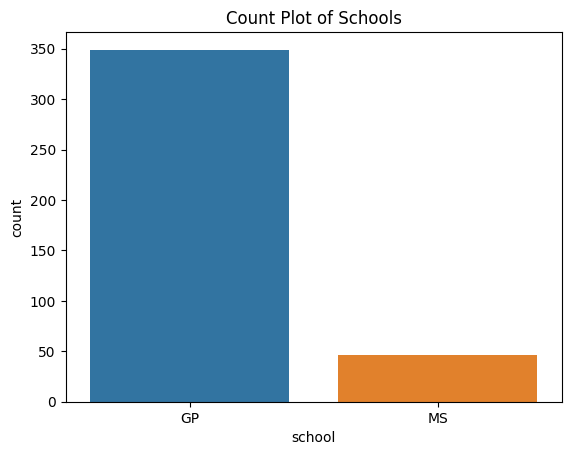

In [7]:
# Count plot of schools
sns.countplot(data=data, x='school')
plt.title('Count Plot of Schools')
plt.show()



# <a id = "6"></a>
# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" > COUNT PLOT OF SEX<br><div>

The code creates a count plot of the sexes in the dataset, displaying the frequency of each sex. This visualization provides an overview of the distribution of students by gender.






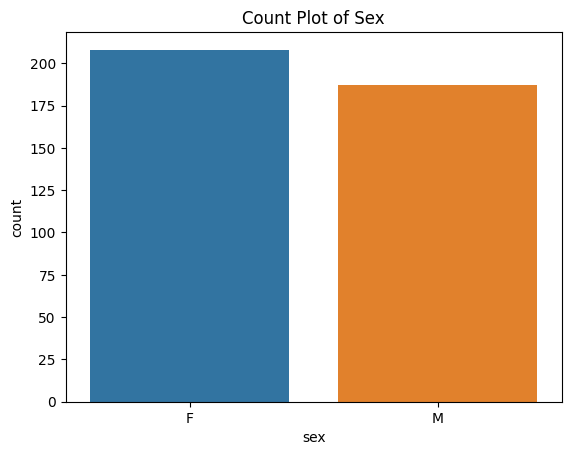

In [8]:
# Count plot of sex
sns.countplot(data=data, x='sex')
plt.title('Count Plot of Sex')
plt.show()



# <a id = "7"></a>
# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" > BOX PLOT OF AGE<br><div>

The code generates a box plot of the variable "age" in the dataset, illustrating the distribution of ages among the students. This visualization displays the quartiles, median, and any potential outliers in the data.



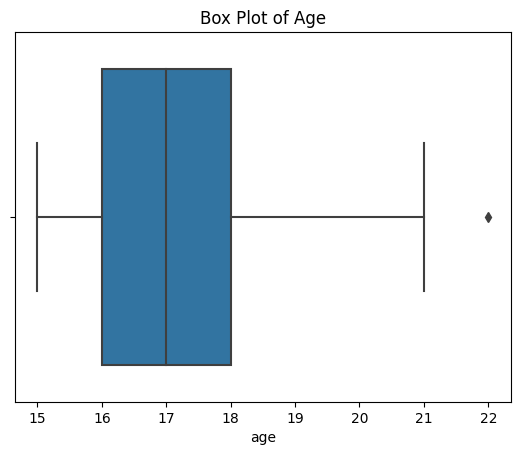

In [9]:
# Box plot of age
sns.boxplot(data=data, x='age')
plt.title('Box Plot of Age')
plt.show()



# <a id = "8"></a>
# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" > COUNT PLOT OF FAMILY SIZE<br><div>

The code creates a count plot to visualize the distribution of family sizes in the dataset. It shows the frequency of each family size category and helps to understand the distribution of students across different family sizes.






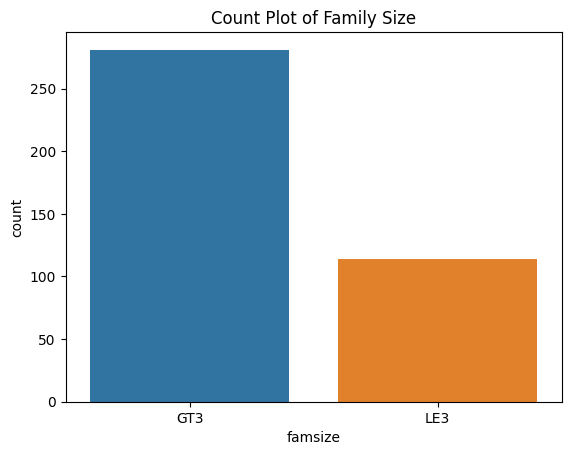

In [10]:
# Count plot of family size
sns.countplot(data=data, x='famsize')
plt.title('Count Plot of Family Size')
plt.show()



# <a id = "9"></a>
# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" > COUNT PLOT OF PARENT'S COHABITATION STATUS<br><div>

The code creates a count plot to visualize the distribution of parent's cohabitation status in the dataset. It shows the frequency of each category of cohabitation status and helps to understand the distribution of students based on their parents' living arrangement.






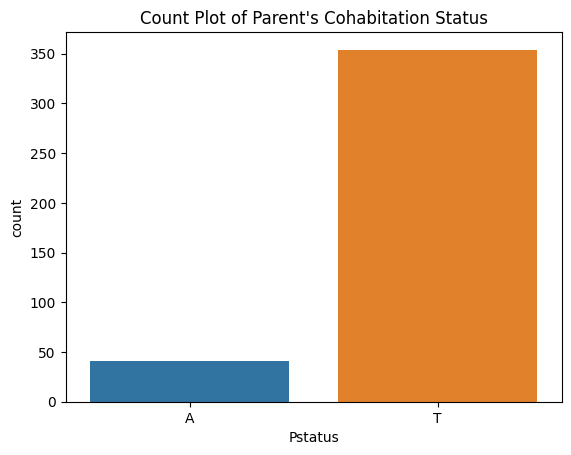

In [11]:
# Count plot of parent's cohabitation status
sns.countplot(data=data, x='Pstatus')
plt.title("Count Plot of Parent's Cohabitation Status")
plt.show()



# <a id = "10"></a>
# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" > COUNT PLOT OF MOTHERS EDUCATION LEVEL<br><div>

The code creates a count plot to visualize the distribution of mother's education level in the dataset. It displays the frequency of each category of education level and provides insights into the educational background of the mothers of



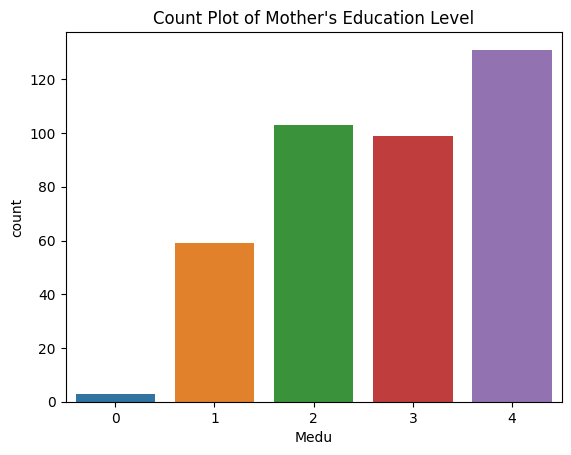

In [12]:
# Count plot of mother's education level
sns.countplot(data=data, x='Medu')
plt.title("Count Plot of Mother's Education Level")
plt.show()



# <a id = "11"></a>
# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" > COUNT PLOT OF FATHER EDUCATION LEVEL<br><div>

The code creates a count plot to visualize the distribution of father's education level in the dataset. It displays the frequency of each category of education level and provides insights into the educational background of the fathers of the students.






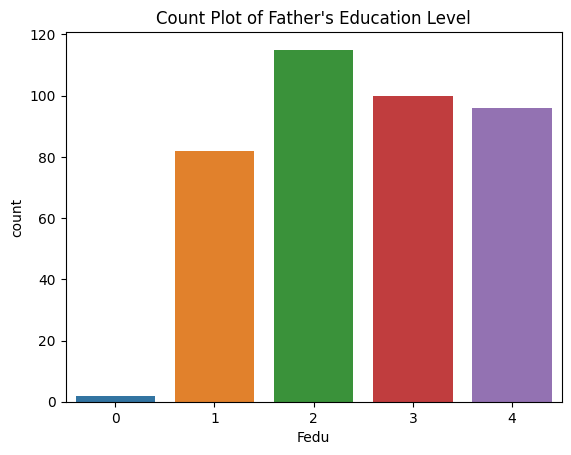

In [13]:
# Count plot of father's education level
sns.countplot(data=data, x='Fedu')
plt.title("Count Plot of Father's Education Level")
plt.show()



# <a id = "12"></a>
# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" > COUNT PLOT OF TRAVEL TIME<br><div>

The code generates a count plot to visualize the distribution of travel time among students. It shows the frequency of different travel time categories and provides insights into how much time students spend traveling to school.



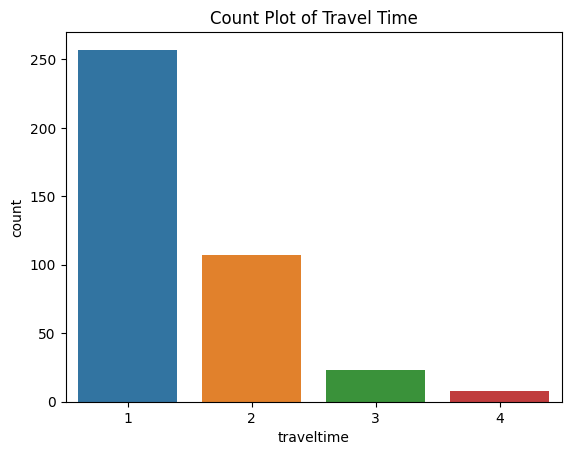

In [14]:
# Count plot of travel time
sns.countplot(data=data, x='traveltime')
plt.title('Count Plot of Travel Time')
plt.show()



# <a id = "13"></a>
# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" > COUNT PLOT OF FAILURES<br><div>

The code generates a count plot to visualize the distribution of failures among students. It shows the frequency of different failure categories and provides insights into the academic performance of students.



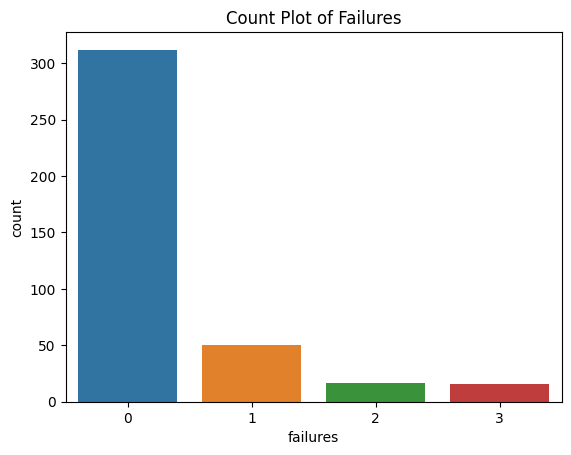

In [15]:
# Count plot of failures
sns.countplot(data=data, x='failures')
plt.title('Count Plot of Failures')
plt.show()

# <a id = "14"></a>
# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" >SUMMARY STATISTICS FOR NUMERICAL COLUMNS<br><div>


The code calculates descriptive statistics (such as count, mean, standard deviation, minimum, maximum, and quartiles) for the numerical columns in the dataset and prints the summary statistics. It provides an overview of the central tendency, dispersion, and distribution of the selected numerical variables.






In [16]:
numerical_columns = ['age', 'Medu', 'Fedu', 'traveltime', 'failures']
numerical_summary = data[numerical_columns].describe()
print(numerical_summary)


              age        Medu        Fedu  traveltime    failures
count  395.000000  395.000000  395.000000  395.000000  395.000000
mean    16.696203    2.749367    2.521519    1.448101    0.334177
std      1.276043    1.094735    1.088201    0.697505    0.743651
min     15.000000    0.000000    0.000000    1.000000    0.000000
25%     16.000000    2.000000    2.000000    1.000000    0.000000
50%     17.000000    3.000000    2.000000    1.000000    0.000000
75%     18.000000    4.000000    3.000000    2.000000    0.000000
max     22.000000    4.000000    4.000000    4.000000    3.000000


# <a id = "15"></a>
# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" >CORRELATION HEATMAP<br><div>


The code computes the correlation matrix for the selected numerical columns in the dataset and visualizes it as a heatmap. The heatmap uses colors to represent the strength and direction of the correlations between variables. It helps identify patterns and relationships between the numerical variables.






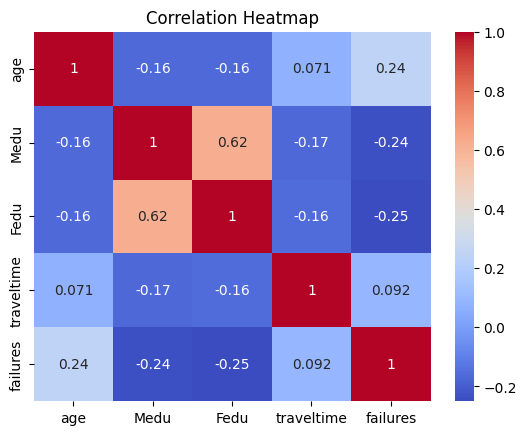

In [17]:
correlation_matrix = data[numerical_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


# <a id = "16"></a>
# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" >DISTRIBUTION OF AGE<br><div>


The code creates a histogram to visualize the distribution of ages in the dataset. The histogram bins the ages into 10 intervals and shows the frequency of occurrences in each bin, providing an overview of the age distribution.






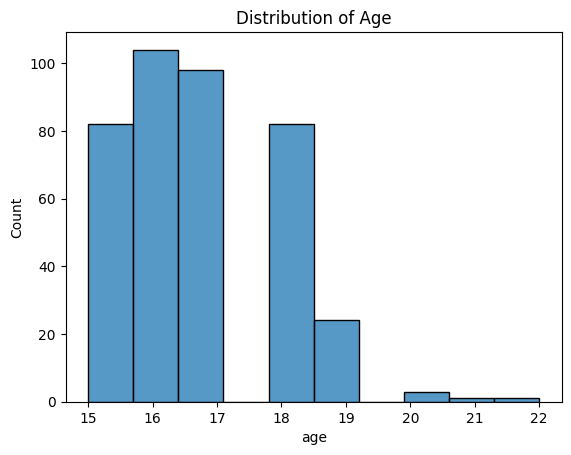

In [18]:
sns.histplot(data=data, x='age', bins=10)
plt.title('Distribution of Age')
plt.show()


# <a id = "17"></a>
# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" >AVERAGE MOTHER'S EDUCATION LEVEL BY FAMILY SIZE
<br><div>


The code generates a bar plot to display the average education level of mothers based on different family sizes. The height of each bar represents the average value of the mother's education level, while the x-axis represents the different family sizes. This visualization allows for a comparison of mother's education levels across family sizes.



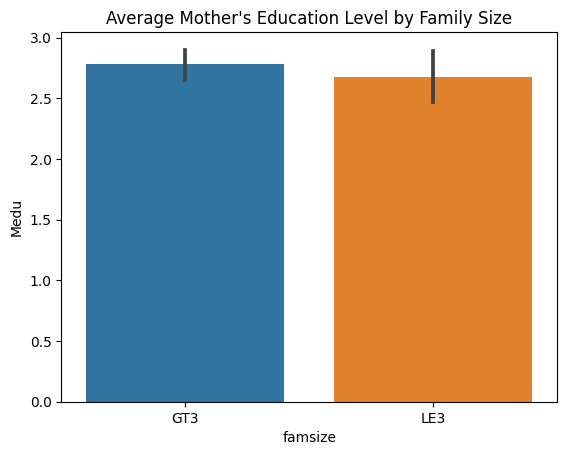

In [19]:
sns.barplot(data=data, x='famsize', y='Medu')
plt.title("Average Mother's Education Level by Family Size")
plt.show()


# <a id = "18"></a>
# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" >SEX COUNT AND PERCENTAGE
<br><div>


The code calculates the count and percentage of each gender in the dataset. It displays the count of each gender and the corresponding percentage.






In [20]:
sex_count = data['sex'].value_counts()
sex_percentage = data['sex'].value_counts(normalize=True) * 100
print("Sex Count:\n", sex_count)
print("\nSex Percentage:\n", sex_percentage)


Sex Count:
 F    208
M    187
Name: sex, dtype: int64

Sex Percentage:
 F    52.658228
M    47.341772
Name: sex, dtype: float64


# <a id = "19"></a>
# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" > CROSS-TABULATION

<br><div>




The code creates a cross-tabulation (contingency table) between the 'sex' and 'Pstatus' variables, counting the occurrences of each combination. It displays the cross-tabulation table.






In [21]:
cross_tab = pd.crosstab(data['sex'], data['Pstatus'])
print(cross_tab)


Pstatus   A    T
sex             
F        23  185
M        18  169



# <a id = "20"></a>
# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" >BOX PLOT - MOTHER'S EDUCATION LEVEL


<br><div>





The code creates a box plot of the 'Medu' variable, which represents the mother's education level. It displays the distribution of the variable and any outliers.






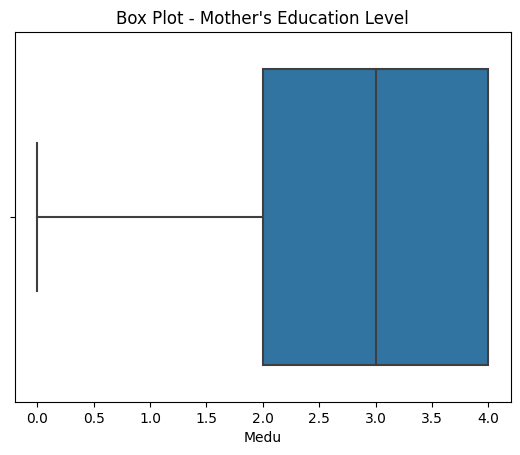

In [22]:
sns.boxplot(data=data, x='Medu')
plt.title("Box Plot - Mother's Education Level")
plt.show()



# <a id = "21"></a>
# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" >VIOLIN PLOT - AGE BY SEX
<br><div>







The code creates a violin plot to visualize the distribution of ages for each sex category. It provides insights into the distribution shape, density, and potential outliers within each group.



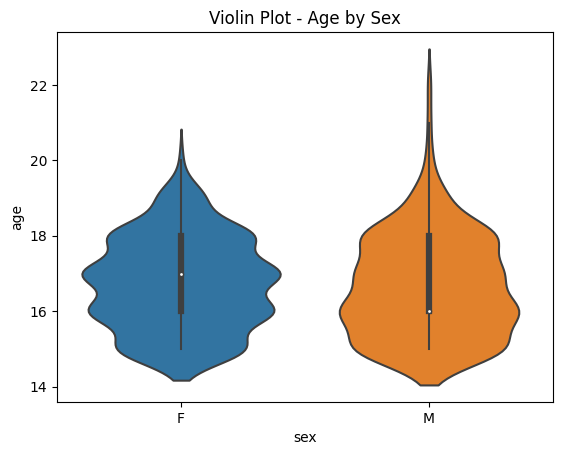

In [23]:
sns.violinplot(data=data, x='sex', y='age')
plt.title("Violin Plot - Age by Sex")
plt.show()



# <a id = "22"></a>
# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" >LOGISTIC REGRESSION

<br><div>








The code performs logistic regression on the dataset to analyze the relationship between the predictors (age, Medu, Fedu, traveltime) and the binary target variable (failures). It uses the statsmodels library to fit the logistic regression model, and the result summary is printed, providing information about the coefficients, significance levels, and goodness-of-fit statistics.






In [24]:
import pandas as pd
import statsmodels.api as sm

# Load the dataset
data = pd.read_csv('data.csv')

# Convert 'failures' to binary format (0 or 1)
data['failures'] = data['failures'].apply(lambda x: 0 if x == 0 else 1)

# Convert categorical variables to dummy variables
categorical_vars = ['school', 'sex', 'famsize', 'Pstatus']
data = pd.get_dummies(data, columns=categorical_vars, drop_first=True)

# Define the predictors and target variable
X = data[['age', 'Medu', 'Fedu', 'traveltime']]
X = sm.add_constant(X)
y = data['failures']

# Perform logistic regression
model = sm.Logit(y, X)
result = model.fit()
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.448868
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               failures   No. Observations:                  395
Model:                          Logit   Df Residuals:                      390
Method:                           MLE   Df Model:                            4
Date:                Wed, 12 Jul 2023   Pseudo R-squ.:                  0.1269
Time:                        02:44:08   Log-Likelihood:                -177.30
converged:                       True   LL-Null:                       -203.08
Covariance Type:            nonrobust   LLR p-value:                 1.711e-10
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.6588      1.935     -4.475      0.000     -12.451      -4.867
age            0.5134      0.



# <a id = "23"></a>
# <div style= "font-family: Times New Roman; font-weight:bold; letter-spacing: 0px; color:WHITE; font-size:120%; text-align:left;padding:3.0px; background: #FF4500; border-bottom: 8px solid WHITE" >DECISION TREE CLASSIFIER
<br><div>









---
## Prepare Data for Modeling


In [ ]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop(columns=['failures'])
    # Sanitize column names for LightGBM/XGBoost compatibility
    X.columns = [str(c).replace(' ', '_').replace('[', '_').replace(']', '_')
                 .replace(',', '_').replace(':', '_').replace('{', '_')
                 .replace('}', '_').replace('<', '_').replace('>', '_')
                 .replace('"', '_') for c in X.columns]
y = df['failures']

# Handle non-numeric columns for modeling
X = pd.get_dummies(X, drop_first=True)
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


---
## Step 1: Baseline Model Comparison (LazyPredict)

Quick automated comparison of multiple models to establish baselines.


In [ ]:
from lazypredict.Supervised import LazyClassifier

lazy_clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = lazy_clf.fit(X_train, X_test, y_train, y_test)

print(models)


---
## Step 2: Final Pipeline (PyCaret)

Automated ML pipeline with PyCaret:
- `setup()` → preprocessing & configuration
- `compare_models()` → model selection
- `finalize_model()` → train on full data


In [ ]:
from pycaret.classification import *

clf_setup = setup(data=df, target='failures', session_id=42, verbose=False)

# Compare models and select best
best_model = compare_models()

# Display comparison results
print(best_model)


In [ ]:
# Evaluate the best model
evaluate_model(best_model)


In [ ]:
# Finalize the model (train on full dataset)
final_model = finalize_model(best_model)

print('Final model:', final_model)